In [ ]:
import torch
from train import learning_experiment, get_log_steps
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from scipy.stats import t
from data import three_mixture, students_t
from excess_curtosis_experiment import quad_tanh, scaled_tanh,  quad, quad_relu

In [ ]:
nits = 10000 #number of iteration steps
d = 100 #data dimension
m = 100 #hidden layer width
eta = 0.01 #learning rate
bs = 100 #batch size
ninits = 10 #number of independent runs to average over
w_norm = 1.0 #weight normalization factor
act = F.tanh #activation function
N = 2 #number of layers in the network
skip = 0 #size of skip connection (0 for no skip connection)

0.0007071067811865475 0.9823438807260927 48.81352519534902
0.00632455532033676 1.0049676611712437 6.901774382440223
0.006708203932499369 0.9818121001495143 2.1872062631403777
0.019764235376052368 0.994665458835281 -0.47211465450178824
-0.012522646152737318 0.9983368753415186 -1.3275126167529927
0.0036 0.9999935199790048 -1.999974079496107
-0.003279566366999694 0.7453487774190012 -1.9999612788755414


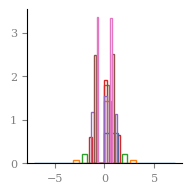

In [ ]:
plt.figure(figsize=(2,2))
for a in [0.01,0.05,0.1,0.2,0.3, 0.5, 0.9]:
    xs = three_mixture(np.ones(10000), a=a).numpy()
    plt.hist(xs, density=True, histtype="step")
    print(np.mean(xs), np.std(xs), np.mean(xs**4)/np.std(xs)**4 -3)


4.01 0.0024425075976032915 0.994321928999689 9.268810534752372
16.04 -0.002907880472442991 0.9956468657940052 0.5120105125336916
28.07 -0.005608487567959638 1.0047784761129774 0.25465284639706054
40.1 0.0031082464420941845 0.9982816347715329 0.1618232238796642


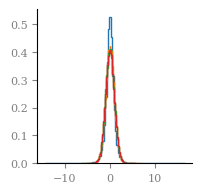

In [ ]:
plt.figure(figsize=(2,2))
for df in np.linspace(4.01,40.1,4):
    xs = students_t(np.ones(100000), df=df).numpy()
    plt.hist(xs, density=True, histtype="step", bins=100)
    print(df,np.mean(xs), np.std(xs), np.mean(xs**4)/np.std(xs)**4 -3)

In [ ]:
import gc
import torch
from tqdm import tqdm

# Outer sweep parameters
activations = [F.relu, F.tanh, quad, quad_relu, quad_tanh]
activations = [scaled_tanh]
ms = [1,10,100,1000]

# Hyperparameters
nits = 30000
d = 100
ninits = 5
eta = 0.001
bs = 100
w_norm = 1
t_val = 0.1
sample_fn = three_mixture

# Directory for saving results
save_dir = "./experiments"


# Sweep loop
for act in activations:
    for m in ms:
        print(f"\nRunning experiment: act={act.__name__}, m={m}")

        # Run experiment (learning_experiment will auto-save)
        results_all = learning_experiment(
            nits=nits,
            d=d,
            m=m,
            ninits=ninits,
            eta=eta,
            bs=bs,
            wnorm=w_norm,
            sample_first_dim=sample_fn,
            Adam=True,
            act=act,
            t=t_val,
            save=True,
        )

        # Free memory explicitly
        del results_all
        gc.collect()
        torch.cuda.empty_cache()

        print(f"Experiment finished: act={act.__name__}, m={m}")


Running experiment: act=scaled_tanh, m=1


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


KeyboardInterrupt: 